# Toy Squares Base DP Evaluation

This notebook evaluates a trained base Diffusion Policy checkpoint on **Early Decision** and **Late Decision** toy scenarios (5 rollouts each), and includes a fixed-action environment sanity check GIF.

In [13]:
import copy
import json
import os
import pickle
import random
import socket
import subprocess
from datetime import datetime
from itertools import permutations
from pathlib import Path

import imageio
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import HTML, Image, display
from matplotlib.collections import LineCollection
from matplotlib.patches import RegularPolygon

import robomimic
import robomimic.envs
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.torch_utils as TorchUtils

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

print("hostname:", socket.gethostname())
print("pid:", os.getpid())
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("cuda device count:", torch.cuda.device_count())
    print("current device:", torch.cuda.current_device())
    subprocess.run(["nvidia-smi", "-L"], check=False)

hostname: mk-c
pid: 1048484
cuda available: True
cuda device count: 1
current device: 0
GPU 0: NVIDIA GeForce RTX 3090 (UUID: GPU-09d77f1f-8992-15cc-7b76-e48a47442fcd)


In [14]:
# Set this to your trained base DP checkpoint
DP_CKPT_PATH = "/scratch/gilbreth/zoellner/diffusion_runs/toy_squares_dp/20260421005349/models/model_epoch_2_data_success_0.0.pth"
DP_CKPT_PATH = "/home/moritz/data/diffusion_runs/toy_squares_dp_n500/20260422190540/models/model_epoch_320_best_validation_0.005075077305082232.pth"

assert Path(DP_CKPT_PATH).exists(), f"Checkpoint not found: {DP_CKPT_PATH}"

device = TorchUtils.get_torch_device(try_to_use_cuda=True)
policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=DP_CKPT_PATH, device=device, verbose=False)
env, _ = FileUtils.env_from_checkpoint(ckpt_dict=ckpt_dict, render=False, render_offscreen=True, verbose=False)

print("Loaded policy and environment successfully.")
print("Environment type:", type(env))


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['agent_pos']
using obs modality: rgb with keys: ['image']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.710221e+07
Created environment with name TouchCube
Action size is 2
ROBOMIMIC WARNING(
    No environment version found in dataset!
    Cannot verify if dataset and installed environment versions match
)
Loaded policy and environment successfully.
Environment type: <class 'robomimic.envs.wrappers.FrameStackWrapper'>


/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:20: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float32. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:25: UserWarning: WARN: It seems a Box observation space is an image but the upper and lower bounds are not in [0, 255]. Generally, CNN policies assume observations are within that range, so you may encounter an issue if the observation values are not.
  logger.warn(


In [16]:
OUTPUT_ROOT = Path("/home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/base_DP")

try:
    from toy_squares.toy_squares_utils import early_decision_cube_setup, late_decision_cube_setup
except ModuleNotFoundError:
    from toy_squares_utils import early_decision_cube_setup, late_decision_cube_setup


def _checkpoint_tag(path_str):
    return Path(path_str).name


def _to_numpy(value):
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def _render_frame(env, height=512, width=512, camera_name="agentview"):
    try:
        return env.render(mode="rgb_array", height=height, width=width, camera_name=camera_name)
    except TypeError:
        return env.render(mode="rgb_array", height=height, width=width)


def _obs_low_level_snapshot(obs):
    snapshot = {}
    for key in ["states", "agent_pos"]:
        if key in obs:
            snapshot[key] = _to_numpy(obs[key]).copy()
    return snapshot


def _stack_or_object(values):
    values = list(values)
    if not values:
        return np.array([])
    try:
        return np.stack(values)
    except Exception:
        return np.array(values, dtype=object)


def run_rollout(policy, env, setup_fn, horizon=200, render=True):
    setup_state = _to_numpy(setup_fn(deterministic=False)).copy()
    obs = env.reset_to(setup_state)
    policy.start_episode()

    total_reward = 0.0
    success = False
    steps = 0

    full_obs = [copy.deepcopy(obs)]
    low_level_obs = [_obs_low_level_snapshot(obs)]
    step_records = []
    frames = []
    if render:
        frames.append(_render_frame(env))

    for t in range(horizon):
        action = _to_numpy(policy(ob=obs)).copy()
        next_obs, reward, done, info = env.step(action)
        reward_value = float(reward)
        total_reward += reward_value
        steps = t + 1
        step_success = bool(info.get("success", False) or reward_value > 0)
        success = success or step_success
        step_record = {
            "t": t,
            "action": action,
            "reward": reward_value,
            "done": bool(done),
            "success": step_success,
            "state": _obs_low_level_snapshot(obs),
        }
        step_records.append(step_record)
        full_obs.append(copy.deepcopy(next_obs))
        low_level_obs.append(_obs_low_level_snapshot(next_obs))
        obs = next_obs
        if render:
            frames.append(_render_frame(env))
        if done or success:
            break

    return {
        "success": float(success),
        "steps": steps,
        "return": total_reward,
        "setup_state": setup_state,
        "full_obs": full_obs,
        "low_level_obs": low_level_obs,
        "step_records": step_records,
        "frames": frames,
    }


def _save_rollout_artifacts(run_dir, rollout):
    run_dir.mkdir(parents=True, exist_ok=True)
    with open(run_dir / "rollout_summary.json", "w", encoding="utf-8") as f:
        json.dump({"success": rollout["success"], "steps": rollout["steps"], "return": rollout["return"]}, f, indent=2)

    with open(run_dir / "full_obs.pkl", "wb") as f:
        pickle.dump(rollout["full_obs"], f)

    with open(run_dir / "step_records.pkl", "wb") as f:
        pickle.dump(rollout["step_records"], f)

    np.savez_compressed(
        run_dir / "low_level_obs.npz",
        states=_stack_or_object([obs.get("states") for obs in rollout["low_level_obs"]]),
        agent_pos=_stack_or_object([obs.get("agent_pos") for obs in rollout["low_level_obs"]]),
    )
    np.save(run_dir / "setup_state.npy", rollout["setup_state"])

    if rollout["frames"]:
        imageio.mimsave(run_dir / "rollout.gif", rollout["frames"], duration=0.12)


def evaluate_scenario(policy, env, setup_fn, scenario_name, n_rollouts=100, horizon=200):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    policy_path_tag = _checkpoint_tag(DP_CKPT_PATH)
    scenario_dir = OUTPUT_ROOT / policy_path_tag / f"n{n_rollouts}_{scenario_name}_h{horizon}_{timestamp}"
    scenario_dir.mkdir(parents=True, exist_ok=True)

    records = []
    all_frames = []

    for rollout_idx in range(n_rollouts):
        rollout = run_rollout(policy, env, setup_fn, horizon=horizon, render=True)
        run_dir = scenario_dir / f"rollout_{rollout_idx:03d}"
        _save_rollout_artifacts(run_dir, rollout)
        records.append({"rollout_idx": rollout_idx, "success": rollout["success"], "steps": rollout["steps"], "return": rollout["return"], "run_dir": str(run_dir)})
        all_frames.extend(rollout["frames"] or [])
        if rollout["frames"]:
            separator = np.zeros_like(rollout["frames"][0])
            all_frames.extend([separator, separator, separator])

    success_rate = float(np.mean([r["success"] for r in records])) if records else 0.0
    avg_steps = float(np.mean([r["steps"] for r in records])) if records else 0.0
    avg_return = float(np.mean([r["return"] for r in records])) if records else 0.0

    summary = {
        "scenario_name": scenario_name,
        "n_rollouts": n_rollouts,
        "horizon": horizon,
        "success_rate": success_rate,
        "avg_steps": avg_steps,
        "avg_return": avg_return,
        "policy_path": DP_CKPT_PATH,
        "scenario_dir": str(scenario_dir),
        "records": records,
    }

    with open(scenario_dir / "scenario_summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2)

    if all_frames:
        imageio.mimsave(scenario_dir / "all_runs.gif", all_frames, duration=0.12)

    return summary

In [17]:
env.reset()
early_results = evaluate_scenario(policy, env, early_decision_cube_setup, "early_decision", n_rollouts=50, horizon=200)
env.reset()
late_results = evaluate_scenario(policy, env, late_decision_cube_setup, "late_decision", n_rollouts=50, horizon=200)

print("Early Decision:", {k: v for k, v in early_results.items() if k != "records"})
print("Late Decision:", {k: v for k, v in late_results.items() if k != "records"})

/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:187: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed `options` to allow the environment initialisation to be passed additional information.
  logger.warn(
/home/moritz/src/guided-diffusion/.pixi/envs/default/lib/python3.10/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'dict'>`
  logger.warn(
/home/moritz/src/guided-diffus

ObservationKeyToModalityDict: states not found, adding states to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: actions not found, adding actions to mapping with assumed low_dim modality!
Early Decision: {'scenario_name': 'early_decision', 'n_rollouts': 50, 'horizon': 200, 'success_rate': 1.0, 'avg_steps': 63.98, 'avg_return': 1.0, 'policy_path': '/home/moritz/data/diffusion_runs/toy_squares_dp_n500/20260422190540/models/model_epoch_320_best_validation_0.005075077305082232.pth', 'scenario_dir': '/home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/base_DP/model_epoch_320_best_validation_0.005075077305082232.pth/n50_early_decision_h200_20260429_001122'}
Late Decision: {'scenario_name': 'late_decision', 'n_rollouts': 50, 'horizon': 200, 'success_rate': 1.0, 'avg_steps': 90.92, 'avg_return': 1.0, 'policy_path': '/home/moritz/data/diffusion_runs/toy_

In [19]:
early_gif = Path(early_results["scenario_dir"]) / "all_runs.gif"
late_gif = Path(late_results["scenario_dir"]) / "all_runs.gif"

def _gif_widget(label, gif_path):
    image = widgets.Image(value=Path(gif_path).read_bytes(), format="gif", layout=widgets.Layout(width="180px"))
    caption = widgets.HTML(f"<b>{label}</b><br>{gif_path}")
    return widgets.VBox([caption, image], layout=widgets.Layout(width="200px", align_items="center"))

display(
    widgets.HBox(
        [
            _gif_widget("Early Decision", early_gif),
            _gif_widget("Late Decision", late_gif),
        ],
        layout=widgets.Layout(gap="12px"),
    )
)

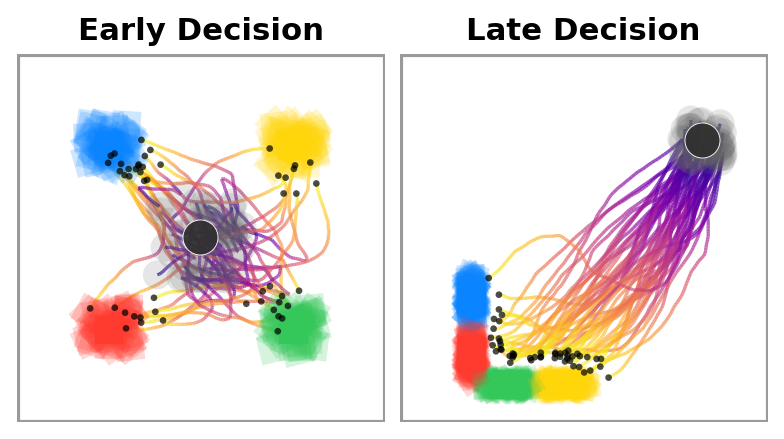

Saved overlay plot to /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/base_DP/model_epoch_320_best_validation_0.005075077305082232.pth/n50_late_decision_h200_20260429_001145/trajectory_overlay_20260429_001341.png


In [20]:
try:
    from toy_squares.toy_squares_utils import plot_early_late_rollouts_overlay
except ModuleNotFoundError:
    from toy_squares_utils import plot_early_late_rollouts_overlay

comparison_dir = Path(late_results["scenario_dir"])
fig, comparison_path = plot_early_late_rollouts_overlay(
    early_rollouts=early_results["records"],
    late_rollouts=late_results["records"],
    output_dir=comparison_dir,
    early_setup_fn=early_decision_cube_setup,
    late_setup_fn=late_decision_cube_setup,
)

display(fig)
plt.close(fig)
print(f"Saved overlay plot to {comparison_path}")